# 02: Exploratory Data Analysis (EDA)

**RetailPulse AI Platform** • *Comprehensive Exploratory Insights*

### Visualizations Included:
1. Daily and 7-day rolling revenue trends.
2. Monthly seasonal revenue trajectory.
3. Top 10 global geographic markets.
4. Day-of-week and peak shopping hour distributions.
5. Distribution histograms and box plots for Quantity, Price, and TotalAmount.
6. Correlation heatmap of numeric transaction variables.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
data_path = os.path.join('..', '..', 'data', 'processed', 'cleaned_transactions.parquet')
df = pd.read_parquet(data_path)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f'Data loaded: {len(df):,} transactions.')

Data loaded: 779,425 transactions.


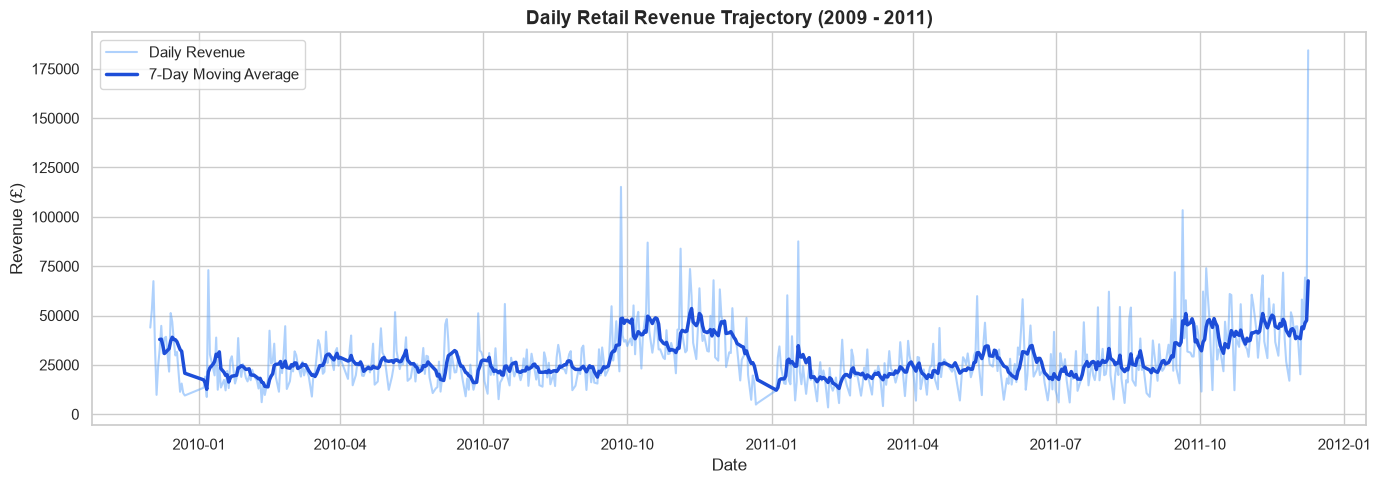

In [2]:
# 1. Revenue Trajectory Over Time
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalAmount'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values, label='Daily Revenue', color='#60A5FA', alpha=0.5)
plt.plot(daily_sales.index, daily_sales.rolling(7).mean(), label='7-Day Moving Average', color='#1D4ED8', lw=2.5)
plt.title('Daily Retail Revenue Trajectory (2009 - 2011)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.tight_layout()
plt.show()

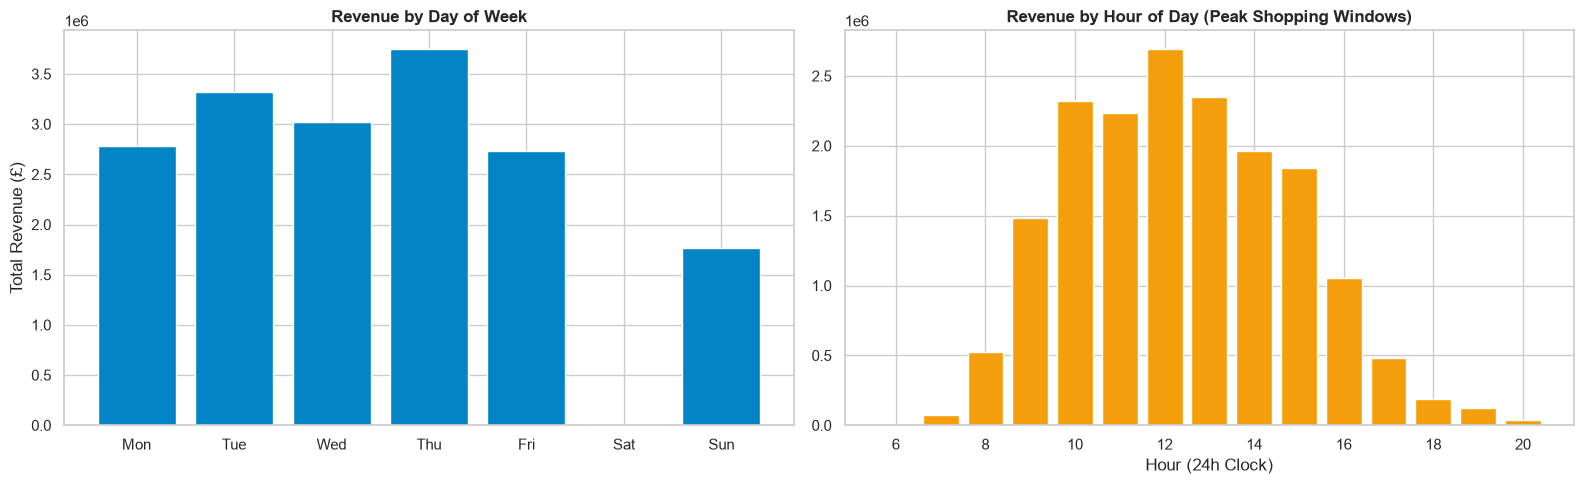

In [3]:
# 2. Temporal Behavioral Patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Day of Week Pattern
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_sales = df.groupby(df['InvoiceDate'].dt.dayofweek)['TotalAmount'].sum()
axes[0].bar([dow_names[i] for i in dow_sales.index], dow_sales.values, color='#0284C7')
axes[0].set_title('Revenue by Day of Week', fontweight='bold')
axes[0].set_ylabel('Total Revenue (£)')

# Hour of Day Pattern
hourly_sales = df.groupby(df['InvoiceDate'].dt.hour)['TotalAmount'].sum()
axes[1].bar(hourly_sales.index, hourly_sales.values, color='#F59E0B')
axes[1].set_title('Revenue by Hour of Day (Peak Shopping Windows)', fontweight='bold')
axes[1].set_xlabel('Hour (24h Clock)')

plt.tight_layout()
plt.show()

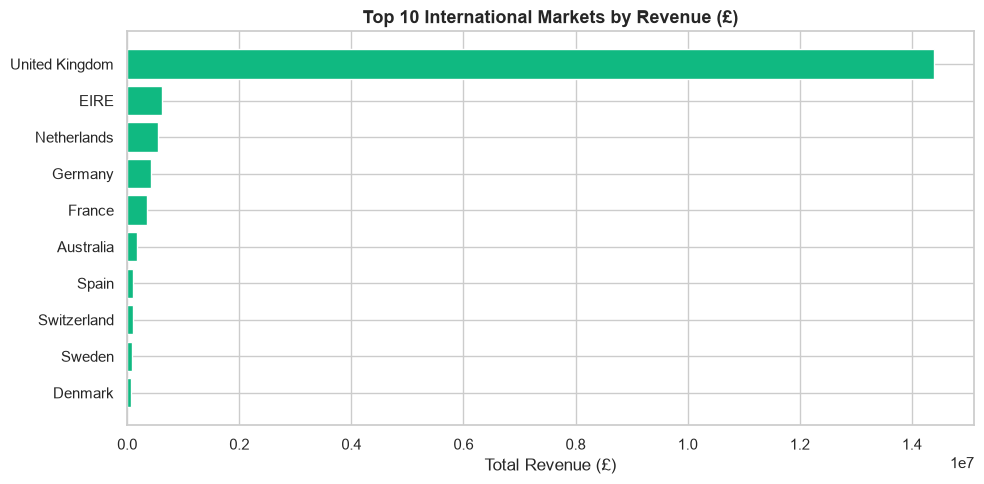

In [4]:
# 3. Geographic Market Distribution
plt.figure(figsize=(10, 5))
top_countries = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.barh(top_countries.index, top_countries.values, color='#10B981')
plt.title('Top 10 International Markets by Revenue (£)', fontsize=13, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

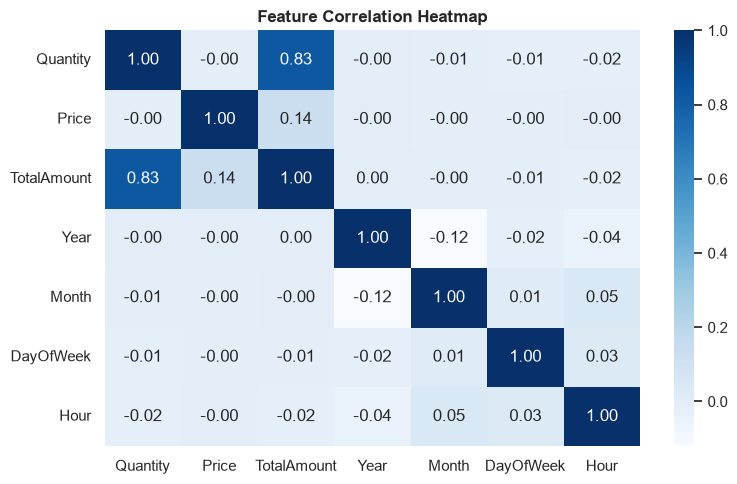

In [5]:
# 4. Correlation Heatmap
plt.figure(figsize=(8, 5))
num_cols = ['Quantity', 'Price', 'TotalAmount', 'Year', 'Month', 'DayOfWeek', 'Hour']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()